In [92]:
import requests
import numpy as np
import json
import pandas as pd
from datetime import datetime, timedelta
import sklearn
end_date = datetime(2024, 6, 1)
start_date = end_date - timedelta(days=6000)

# Additional Possible Features if time allows it
look into : https://www.investopedia.com/top-7-technical-analysis-tools-4773275

In [93]:
API_KEY = "wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4"

ticker = "AMZN"

url_hist_stock_price = f"https://financialmodelingprep.com/stable/historical-price-eod/light?symbol={ticker}&from={start_date.date()}&to={end_date.date()}&apikey={API_KEY}"

# Historical Data Request
response_hist_stock_price = requests.get(url_hist_stock_price)

json_response_hist_stock_price = response_hist_stock_price.json()

df_stock_hist = pd.DataFrame(json_response_hist_stock_price)

df_stock_hist['date'] = pd.to_datetime(df_stock_hist['date'])
df_stock_hist['price'] = df_stock_hist['price'].astype(float)
df_stock_hist['volume'] = df_stock_hist['volume'].astype(float)


df_stock_hist.set_index('date', inplace=True)
df_stock_hist.drop(columns=['symbol'])

closing_price = df_stock_hist[['price']]
i_volume = df_stock_hist[['volume']]
volume =i_volume.apply(np.log10)

In [94]:
# Daily Return
daily_return = closing_price.pct_change()
# 5-Day Return
ret_5d = closing_price.pct_change(5)
# 10-Day Return
ret_10d = closing_price.pct_change(10)

# 5-Day Volatility (Std Dev of Returns)
vol_5d = closing_price.pct_change().rolling(window=5).std()

# 10-Day Volatility
vol_10d = closing_price.pct_change().rolling(window=10).std()

# Momentum (10d)
momentum_10d = closing_price - closing_price.shift(10)

# SMA_10/SMA_50 Ratio
sma_10 = closing_price.rolling(window=10).mean()
sma_50 = closing_price.rolling(window=50).mean()
sma_ratio = sma_10/sma_50

# Z-score (20d)
rolling_mean = closing_price.rolling(window=20).mean()
rolling_std = closing_price.rolling(window=20).std()
z_score_20d = (closing_price - rolling_mean)/rolling_std

# RSI (14d)
delta = closing_price.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/avg_loss
rsi_14 = 100 - (100 / (1 + rs))

y = closing_price.pct_change(-30)

avrg = y.mean()

y.columns = ['y']


dataframes = [
    (daily_return, 'ret_1d'),
    (ret_5d, 'ret_5d'),
    (ret_10d, 'ret_10d'),
    (vol_5d, 'vol_5d'),
    (vol_10d, 'vol_10d'),
    (momentum_10d, 'momentum_10d'),
    (sma_ratio, 'sma_ratio_10_50'),
    (z_score_20d, 'zscore_20d'),
    (rsi_14, 'rsi_14'),
    (volume,'volume'),
    (y,'y'),
]

df_features_short_term = pd.concat(
    [df.rename(columns={df.columns[0]: name}) for df, name in dataframes],
    axis=1
).dropna()



In [95]:
print(y.max())

y    0.64
dtype: float64


              ret_1d    ret_5d   ret_10d    vol_5d   vol_10d  momentum_10d  \
date                                                                         
2024-03-21 -0.177168 -0.178661 -0.525891 -1.174665 -0.829641     -1.860259   
2024-03-20  0.057942 -0.098040  0.004329 -1.165731 -1.302116     -0.369586   
2024-03-19 -0.679745 -0.207958 -0.492599 -1.024326 -1.449999     -1.739711   
2024-03-18 -0.413576 -0.625447 -0.466774 -1.335900 -1.466625     -1.651506   
2024-03-15  0.037857 -0.512706 -0.502475 -1.264468 -1.485698     -1.751472   
2024-03-14  1.507940  0.241197  0.028603 -0.230868 -0.866192     -0.304902   
2024-03-13 -0.657664 -0.086907 -0.150279 -0.100237 -0.792931     -0.787092   
2024-03-12 -0.329110  0.073920 -0.113846 -0.195825 -0.806546     -0.681245   
2024-03-11 -1.084318 -0.234180 -0.638018  0.053840 -0.712619     -2.104294   
2024-03-08  1.209400  0.293616 -0.179519  0.377468 -0.438242     -0.860596   
2024-03-07  0.547594 -0.136875  0.059322 -0.066801 -0.396953    

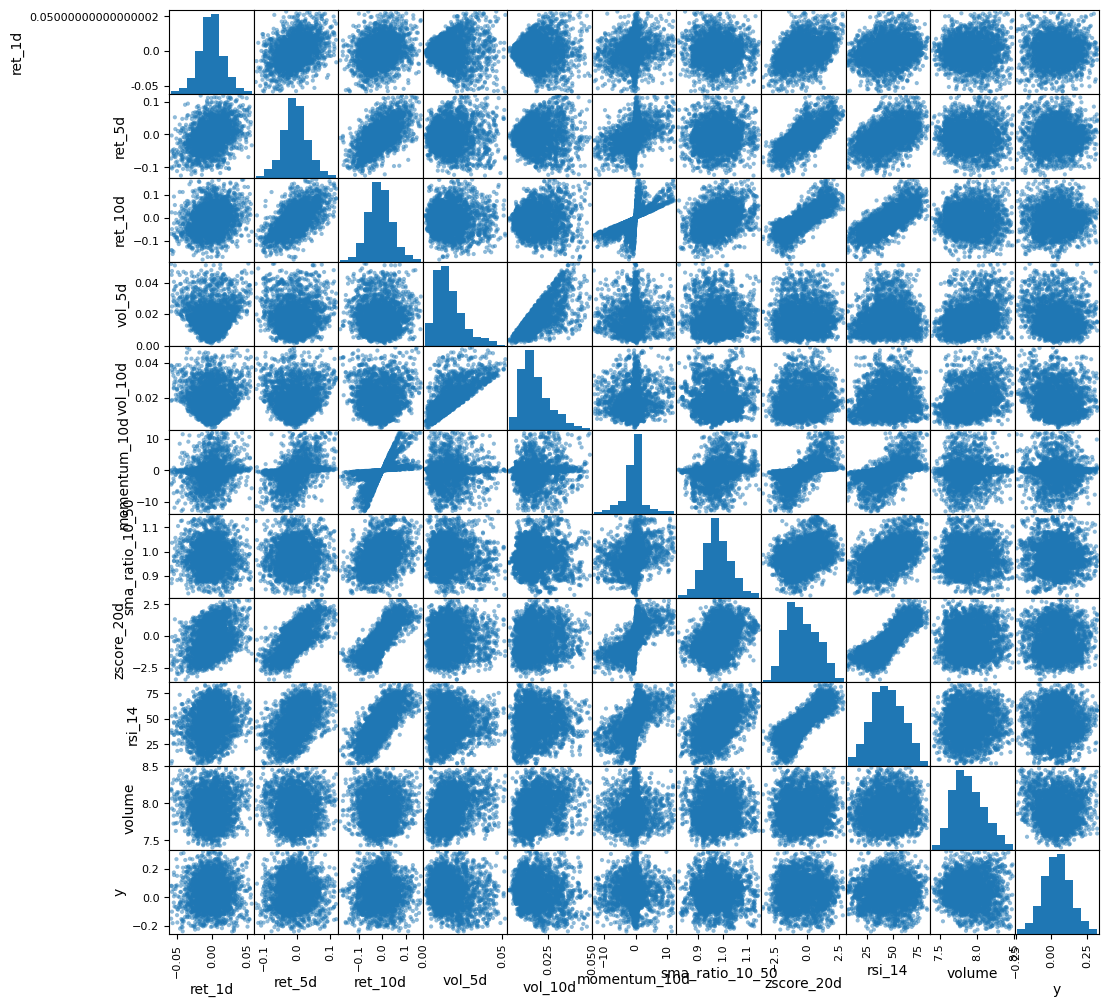

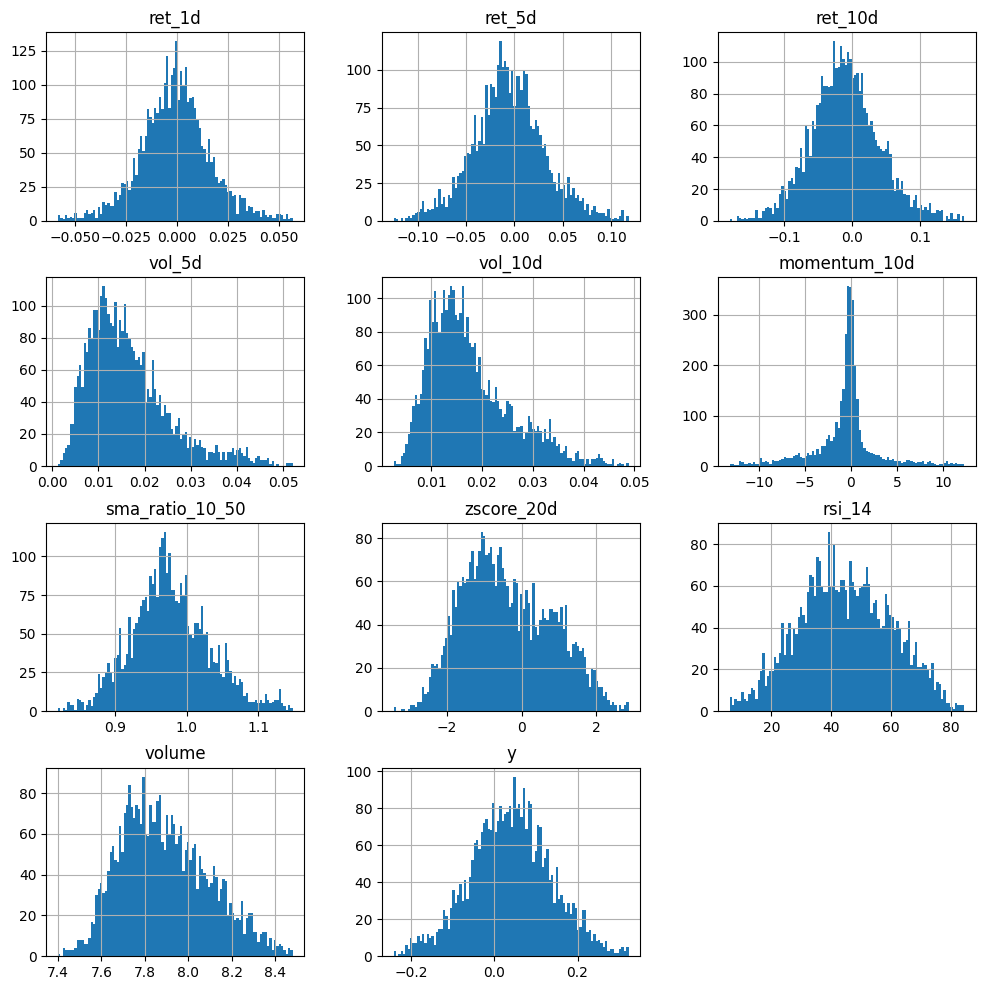

In [96]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Calculate Z-scores for the dataset
z_scores = np.abs(zscore(df_features_short_term))

# Set a threshold for identifying outliers (commonly 3)
threshold = 2.5 # confidence interval of data around 97.6 %.

# Identify rows where any column has a Z-score greater than threshold
outliers = (z_scores > threshold).any(axis=1)

# Remove outliers
df_no_outliers = df_features_short_term[~outliers]


# DATA ANALYSIS

from pandas.plotting import scatter_matrix

scatter_matrix(df_no_outliers, figsize=(12, 12), diagonal='hist')  # or 'kde'
df_no_outliers.hist(figsize=(12, 12), bins=100)

X_data = df_no_outliers.drop(columns=['y'])
y = df_no_outliers['y']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_data)
X_scaled = scaler.transform(X_data)
X = pd.DataFrame(X_scaled, index=X_data.index, columns=X_data.columns)
print(X)


In [97]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error 

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Sample time series data
# Split data between test set and train

import pandas as pd

# Ensure Date column is datetime type and sort the data
def train_test_split(df, ratio=0.2):

    num_instances = df.shape[0]

    split_index = int(num_instances * (1 - ratio))
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]
    return (train_df,test_df)

X_train, X_test = train_test_split(X)
y_train, y_test = train_test_split(y)



# Use Kfold validation to tune hyperparameters using the train dataset
X_train_arr = X_train.values
y_train_arr = y_train.values

tscv = TimeSeriesSplit(n_splits=5)

val_rmse_scores = []
for i, (train_index, val_index) in enumerate(tscv.split(X_train_arr)):
    print(f"Split {i+1}: Train {len(train_index)}, Test {len(val_index)}")

    X_train_i, X_val_i = X_train_arr[train_index], X_train_arr[val_index]
    y_train_i, y_val_i = y_train_arr[train_index], y_train_arr[val_index]

    model = xgb.XGBRegressor(n_estimators=1000, 
                             early_stopping_rounds=50, 
                             learning_rate=0.01)

    model.fit(
        X_train_i, y_train_i,
        eval_set=[(X_train_i,y_train_i),(X_val_i, y_val_i)],
        verbose=100
    )
    
    preds = model.predict(X_val_i)
    rmse = root_mean_squared_error(y_val_i, preds)
    val_rmse_scores.append(rmse)

# Have a metric for directional accuracy to evaluate the impact of different hyperparameters
print(val_rmse_scores)
final_rmse = np.mean(val_rmse_scores)
print(f"\nFinal average RMSE across all folds: {final_rmse:.4f}")



model = xgb.XGBRegressor(n_estimators=1000,early_stopping_rounds=50,learning_rate=0.01)

model.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=100) # not sure about this

final_pred = model.predict(X_test)

print(root_mean_squared_error(y_test, final_pred))


Split 1: Train 464, Test 459
[0]	validation_0-rmse:0.10724	validation_1-rmse:0.09118
[49]	validation_0-rmse:0.08127	validation_1-rmse:0.09654
Split 2: Train 923, Test 459
[0]	validation_0-rmse:0.09939	validation_1-rmse:0.08954
[61]	validation_0-rmse:0.07477	validation_1-rmse:0.09235
Split 3: Train 1382, Test 459
[0]	validation_0-rmse:0.09598	validation_1-rmse:0.08402
[93]	validation_0-rmse:0.07180	validation_1-rmse:0.08371
Split 4: Train 1841, Test 459
[0]	validation_0-rmse:0.09308	validation_1-rmse:0.10693
[51]	validation_0-rmse:0.08007	validation_1-rmse:0.10798
Split 5: Train 2300, Test 459
[0]	validation_0-rmse:0.09599	validation_1-rmse:0.08780
[100]	validation_0-rmse:0.07988	validation_1-rmse:0.08604
[119]	validation_0-rmse:0.07827	validation_1-rmse:0.08642
[0.09117756554867977, 0.0890842606668399, 0.08278970899329302, 0.10688433184384574, 0.08555961281352256]

Final average RMSE across all folds: 0.0911
[0]	validation_0-rmse:0.10802
[52]	validation_0-rmse:0.11053
0.108011967531605

<Axes: title={'center': 'Feature Importance'}>

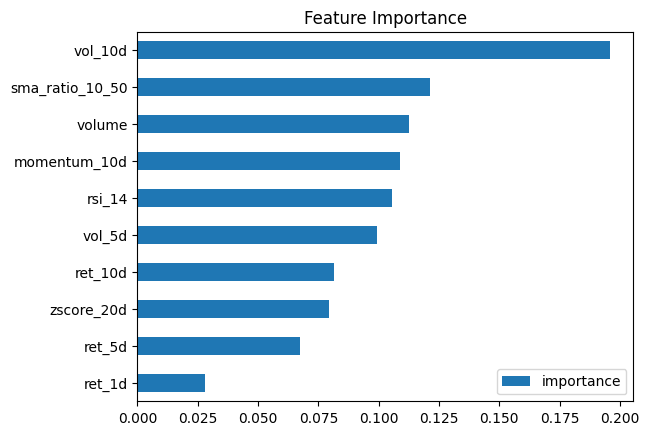

In [98]:
fi = pd.DataFrame(data = model.feature_importances_,index=model.feature_names_in_,columns=['importance'])
fi.sort_values('importance').plot(kind='barh',title='Feature Importance')


In [99]:
y_pred = model.predict(X_test)
pd.set_option('display.max_rows', None)
result = pd.DataFrame()
result['y'] = y_test
result['y_pred'] = y_pred
result['diff'] = y_test-y_pred
result['sign'] = np.sign(result['y']) == np.sign(result['y_pred'])
print(result)
same_sign = (result['sign']).sum()
print(result['diff'].mean())
print(same_sign/len(y_pred))

                   y    y_pred      diff   sign
date                                           
2011-09-16  0.188679  0.036714  0.151966   True
2011-09-15  0.080000  0.036714  0.043286   True
2011-09-14  0.050992  0.036714  0.014278   True
2011-09-13 -0.008130  0.036714 -0.044844  False
2011-09-12 -0.026954  0.036714 -0.063668  False
2011-09-09 -0.056250  0.036714 -0.092964  False
2011-09-08 -0.024259  0.036714 -0.060972  False
2011-09-07  0.027077  0.036714 -0.009636   True
2011-09-06  0.013121  0.036714 -0.023593   True
2011-09-02 -0.030471  0.036714 -0.067185  False
2011-09-01 -0.002814  0.036714 -0.039528  False
2011-08-31 -0.001855  0.038983 -0.040839  False
2011-08-30 -0.032110  0.039825 -0.071935  False
2011-08-29 -0.023629  0.035782 -0.059411  False
2011-08-26 -0.063910  0.037132 -0.101041  False
2011-08-25 -0.087452  0.037132 -0.124584  False
2011-08-24 -0.092697  0.037132 -0.129828  False
2011-08-23 -0.083333  0.038245 -0.121578  False
2011-08-19 -0.179652  0.038008 -0.217659